# Midterm Project – Exploratory Data Analysis and Data Preprocessing

This midterm project focuses on applying the data analysis and preprocessing techniques learned in our Intro to Machine Learning course to a real-world-style healthcare dataset. Our team selected a raw Patient Health Records dataset containing 10,000 patient records with demographic, health, medical, and follow-up information.

The original dataset contains missing values, inconsistent data formats, invalid values, categorical variables, numerical variables, dates, and other data-quality issues. These characteristics provide an opportunity to demonstrate the data cleaning and preprocessing techniques required for preparing a dataset for machine learning.

The main objective of this project is to transform the raw dataset into a clean and machine-learning-ready dataset using Python and Jupyter Notebook. Throughout the project, we will perform exploratory data analysis, identify and handle missing and invalid values, standardize inconsistent data, perform feature engineering, encode categorical variables, scale numerical features, normalize selected distributions, and address class balance in the training data.

The dataset will be divided into 70% training data and 30% testing data using Python. Exploratory analysis and preprocessing decisions will be developed using the training data to help prevent data leakage. The testing data will be kept separate for later evaluation.

Our proposed machine learning problem is **binary classification**, where the goal is to predict whether a patient has a disease based on available demographic and health-related features. The target variable for this project is `Has_Disease`.

This project will demonstrate how raw, imperfect data can be systematically transformed into a reliable dataset that can later be used to train and evaluate machine learning models.


# Group Introduction

Our Group's Members:

-Tien Manh Nguyen

-Viktoriya Kurmisheva

-Zaid Alayedy



Our group is working together to explore and preprocess a Patient Health Records dataset as part of the Midterm Exploratory Data Analysis project. Each member of the group will contribute to different parts of the data analysis, preprocessing, documentation, and evaluation process.

Our team will work collaboratively throughout the project to understand the raw dataset, identify data-quality problems, apply appropriate preprocessing techniques, and document the reasoning behind each decision. We will also review each other's work to ensure that the final notebook follows the requirements of the course and that all data transformations are performed using Python rather than manually modifying the original dataset.

The project will give our group practical experience with the complete data-preparation workflow, from examining raw data to producing a clean dataset that can be used for future machine learning tasks.


## 1. Import Libraries

In this project, we will use several Python libraries to inspect, clean, visualize, and preprocess the patient health records dataset. Pandas will be used for loading and manipulating the dataset, NumPy will support numerical operations, and Matplotlib will be used to visualize data distributions and compare the dataset before and after preprocessing.

Additional Scikit-learn preprocessing tools will be introduced later as they are needed for tasks such as splitting the dataset, handling missing values, encoding categorical variables, scaling numerical features, and preparing the data for machine learning.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Raw Dataset

We begin by loading the original raw Patient Health Records dataset into a Pandas DataFrame. At this stage, the dataset will remain unchanged. The purpose of this step is to establish the original state of the data before performing any cleaning or preprocessing.

Keeping the raw dataset unchanged allows us to compare the original data with the final processed dataset and demonstrate how each preprocessing technique affects the data.


In [33]:
from pathlib import Path
from google.colab import files

raw_csv_path = Path("Patient_Health_Records_Raw.csv")

# Only ask for an upload if the raw dataset is not already present.
if not raw_csv_path.exists():

    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError(
            "No raw dataset was uploaded."
        )

    uploaded_name = next(iter(uploaded.keys()))
    raw_csv_path = Path(uploaded_name)

# Load and preserve the original raw dataset.
df_raw = pd.read_csv(raw_csv_path)

# Separate copy for initial viewing only.
df = df_raw.copy()

print("Raw dataset loaded successfully!")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

Raw dataset loaded successfully!
Rows: 10000
Columns: 17


## 3. Create the Required 70/30 Train-Test Split Before EDA

The professor requires exploratory data analysis to be performed **only on the training data**, while the testing dataset remains untouched.

Because this is a supervised binary-classification problem, the target must first contain a known label. Therefore, the only operation performed before the split is the minimum target preparation needed to keep records where `Has_Disease` is clearly `0` or `1`.

The labeled data is then divided into:

- **70% training data**
- **30% testing data**

`stratify` preserves the class proportions, and `random_state=42` makes the split reproducible.

After this cell, all EDA and preprocessing development uses the training data only.


In [34]:
from sklearn.model_selection import train_test_split
from pathlib import Path

# ============================================================
# LOAD RAW DATA IF IT IS NOT ALREADY AVAILABLE
# ============================================================

# This makes the cell safe to run even if the earlier
# raw-data loading cell was not executed.
if "df_raw" not in globals():

    candidate_files = [
        Path("Patient_Health_Records_Raw.csv")
    ]

    raw_csv_path = next(
        (
            path
            for path in candidate_files
            if path.exists()
        ),
        None
    )

    # If the raw CSV is not available, ask for an upload.
    if raw_csv_path is None:

        try:
            from google.colab import files

            uploaded = files.upload()

            if not uploaded:
                raise FileNotFoundError(
                    "No CSV file was uploaded."
                )

            raw_csv_path = Path(
                next(iter(uploaded.keys()))
            )

        except ModuleNotFoundError:

            raise FileNotFoundError(
                "Patient_Health_Records_Raw.csv was not found. "
                "Place the CSV in the same folder as the notebook."
            )

    # Load and preserve the original raw dataset.
    df_raw = pd.read_csv(raw_csv_path)


# ============================================================
# PREPARE TARGET FOR THE REQUIRED SPLIT
# ============================================================

# Create a temporary labeled copy only for the split.
df_labeled = df_raw.copy()

# Convert the target to numeric.
# "unknown" and other non-numeric values become NaN.
df_labeled["Has_Disease"] = pd.to_numeric(
    df_labeled["Has_Disease"],
    errors="coerce"
)

# Keep only records with a known binary target.
df_labeled = df_labeled[
    df_labeled["Has_Disease"].isin([0, 1])
].copy()

df_labeled["Has_Disease"] = (
    df_labeled["Has_Disease"]
    .astype(int)
)


# ============================================================
# 70/30 TRAIN-TEST SPLIT
# ============================================================

train_df, test_df_untouched = train_test_split(
    df_labeled,
    test_size=0.30,
    random_state=42,
    stratify=df_labeled["Has_Disease"]
)

# Keep independent copies.
train_df = train_df.copy()
test_df_untouched = test_df_untouched.copy()

# All EDA and preprocessing below use the training portion only.
df = train_df.copy()


# ============================================================
# VERIFY THE SPLIT
# ============================================================

print("70/30 train-test split completed successfully.")

print("\nLabeled records:", len(df_labeled))
print("Training records:", len(train_df))
print("Testing records:", len(test_df_untouched))

print(
    "\nTraining percentage:",
    round(
        len(train_df) /
        len(df_labeled) * 100,
        2
    ),
    "%"
)

print(
    "Testing percentage:",
    round(
        len(test_df_untouched) /
        len(df_labeled) * 100,
        2
    ),
    "%"
)

print("\nEDA will use training data only.")
print(
    "The testing dataset will remain separate and untouched."
)

70/30 train-test split completed successfully.

Labeled records: 4974
Training records: 3481
Testing records: 1493

Training percentage: 69.98 %
Testing percentage: 30.02 %

EDA will use training data only.
The testing dataset will remain separate and untouched.


## 4. Preview the Training Dataset

We first preview the training records to understand the available variables and identify visible data-quality problems.

Only the training dataset is displayed.


In [35]:
# Display the first five TRAINING records.
display(df.head())

,Patient_ID,Name,Age,Gender,City,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Last_Visit_Date,Follow_Up,Diagnosis_Code,Notes,Has_Disease
5018,ID-05019,John Doe,-5,NaN,Chicago,22.5,NaN,eighty,normal,N,No,"aspirin,metformin",04/11/2022,NaN,B20,Patient feeling fine 🙂,1
9262,ID-09263,Jane Doe,250,M,NY,26.2,131/63,500,NaN,Yes,Former,Lisinopril / Metformin,20201013,NaN,E11.9,NaN,0
3631,ID-03632,"LEE, Sara",29,NaN,Boston,22.5,115/100,500,250,no,No,NaN,Apr 01 2021,two weeks,E11.9,Follow up soon,0
365,ID-00366,michael brown,250,NaN,New York,NaN,120 over 80,0,normal,N,NaN,NaN,18/02/2022,two weeks,I10,NaN,1
8983,ID-08984,Jane Doe,250,F,Boston,22.5,120/80,70,normal,no,NaN,NaN,27/02/2020,two weeks,B20,"BP high, needs recheck",1


## 5. Inspect the Training Dataset Structure

The training dataset structure shows the number of records, column names, data types, and non-null counts.

Many columns that should eventually be numerical are currently stored as text because they contain inconsistent formats or invalid values.

In [36]:
# Inspect the structure and data types of the raw dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3481 entries, 5018 to 2914
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         3320 non-null   object
 1   Name               3481 non-null   object
 2   Age                3481 non-null   object
 3   Gender             2887 non-null   object
 4   City               3107 non-null   object
 5   BMI                2643 non-null   object
 6   Blood_Pressure     2754 non-null   object
 7   Heart_Rate         3481 non-null   object
 8   Cholesterol_Level  2740 non-null   object
 9   Diabetic           2890 non-null   object
 10  Smoker             2358 non-null   object
 11  Medications        2100 non-null   object
 12  Last_Visit_Date    3481 non-null   object
 13  Follow_Up          2601 non-null   object
 14  Diagnosis_Code     2901 non-null   object
 15  Notes              2080 non-null   object
 16  Has_Disease        3481 non-null   int64 
dt

## 6. Analyze Missing Values in the Training Data

Missing values are counted before preprocessing so that later decisions can be based on the training data only.

The percentage of missing values is also calculated to show which variables need the most attention.

In [37]:
# Calculate the number of missing values in each column
missing_count = df.isnull().sum()

# Calculate the percentage of missing values
missing_percent = (missing_count / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percent
})

# Sort from highest to lowest percentage
missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Notes,1401,40.247055
Medications,1381,39.672508
Smoker,1123,32.260845
Follow_Up,880,25.280092
BMI,838,24.073542
Cholesterol_Level,741,21.286986
Blood_Pressure,727,20.884803
Gender,594,17.064062
Diabetic,591,16.977880
Diagnosis_Code,580,16.661879


## 7. Check Duplicate Training Records

Duplicate records can cause the same observation to influence the analysis more than once.

We check the training dataset for completely duplicated rows before preprocessing.

In [38]:
# Count completely duplicated rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 8. Inspect Categorical and Text Variables

Before categorical preprocessing begins, we inspect the values present in the main categorical and text columns.

This reveals inconsistent labels such as different spellings or abbreviations of the same category.

In [39]:
# Inspect important categorical/text variables using TRAINING data only.
categorical_eda_columns = [
    "Gender",
    "City",
    "Diabetic",
    "Smoker",
    "Medications",
    "Notes"
]

for column in categorical_eda_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Gender ---
Gender
Unknown    608
NaN        594
FEMALE     583
male       576
F          574
M          546
Name: count, dtype: int64

--- City ---
City
Chicago        377
NaN            374
NY             364
Boston         355
la             353
New York       352
Nwe Yrok       344
chicago        339
newyork        332
Los Angeles    291
Name: count, dtype: int64

--- Diabetic ---
Diabetic
no         621
NaN        591
N          586
Unknown    568
Yes        567
y          548
Name: count, dtype: int64

--- Smoker ---
Smoker
NaN          1123
No            597
Former        596
EX-smoker     596
yes           569
Name: count, dtype: int64

--- Medications ---
Medications
NaN                       1381
Lisinopril / Metformin     731
aspirin,metformin          693
Aspirin; Metformin         676
Name: count, dtype: int64

--- Notes ---
Notes
NaN                       1401
BP high, needs recheck     742
Follow up soon             679
Patient feeling fine 🙂     659
Name: count, dty

## 9. Inspect Numerical-Looking Variables

Several variables represent numerical information but are stored as text because the raw data includes words, units, invalid measurements, or mixed formats.

We inspect representative values before creating cleaning rules.

In [40]:
# Inspect numerical-looking variables using TRAINING data only.
numerical_eda_columns = [
    "Age",
    "BMI",
    "Heart_Rate",
    "Cholesterol_Level",
    "Follow_Up"
]

for column in numerical_eda_columns:
    print(f"\n--- {column} ---")
    print(
        df[column]
        .value_counts(dropna=False)
        .head(20)
    )


--- Age ---
Age
-5        904
twenty    851
250       841
6          19
5          19
71         17
10         16
75         15
72         15
11         14
59         14
35         13
89         12
97         12
26         12
16         12
19         11
61         11
53         11
95         11
Name: count, dtype: int64

--- BMI ---
BMI
22.5       878
22kg/m2    855
NaN        838
22.6        10
21.8        10
29.8        10
18.5        10
19.2        10
27.6         9
16.8         9
20.2         9
17.7         8
19.6         8
17.5         8
27.9         8
19.1         8
16.5         8
18.3         8
24.6         8
24.8         8
Name: count, dtype: int64

--- Heart_Rate ---
Heart_Rate
500       888
eighty    876
0         838
97         22
119        20
109        20
64         19
55         18
89         18
87         17
95         17
80         17
108        17
67         16
56         16
107        16
50         16
79         15
54         15
106        15
Name: count, dtype: int

## 10. Inspect Blood Pressure and Date Formats

`Blood_Pressure` and `Last_Visit_Date` both contain multiple text formats.

Blood pressure will later be split into systolic and diastolic features, while the visit date will be converted to datetime and used to create numerical date features.


In [41]:
print("===== Blood Pressure Formats =====")
print(
    df["Blood_Pressure"]
    .value_counts(dropna=False)
    .head(20)
)

print("\n===== Last Visit Date Formats =====")
print(
    df["Last_Visit_Date"]
    .value_counts(dropna=False)
    .head(20)
)

===== Blood Pressure Formats =====
Blood_Pressure
NaN            727
120/80         712
120 over 80    684
120 - 80       650
97/64            3
147/95           3
148/86           3
110/75           3
90/98            3
106/60           2
159/90           2
157/95           2
143/80           2
125/95           2
90/73            2
98/61            2
113/78           2
117/64           2
145/81           2
91/92            2
Name: count, dtype: int64

===== Last Visit Date Formats =====
Last_Visit_Date
20221117       5
2024-05-22     4
20250727       4
10/12/2024     4
27/11/2023     4
27/04/2023     4
Mar 19 2023    4
20200716       4
20240823       4
20250813       3
06/07/2020     3
20230913       3
2024-09-22     3
Aug 18 2023    3
2020-11-06     3
2020-09-21     3
2024-08-12     3
03/03/2023     3
20220512       3
08/03/2021     3
Name: count, dtype: int64


## 11. Analyze the Training Target Distribution

`Has_Disease` is the binary target variable.

The valid target labels were required before the train/test split, so the training target now contains only `0` and `1`. We examine its class distribution before balancing.


## 12. Data Preprocessing Plan

The following plan summarizes how each variable will be prepared for machine learning. All changes will be completed through Python so the original dataset remains unchanged.

| Original Column | Planned Action | Reason |
|---|---|---|
| `Patient_ID` | Remove | Identifier; does not describe patient health and may expose unnecessary personal information |
| `Name` | Remove | Personal identifier; does not provide useful predictive health information |
| `Age` | Standardize inconsistent values, convert to numeric, and validate range | Prepare Age as a usable numerical demographic feature |
| `Gender` | Standardize and One-Hot Encode | Convert the categorical feature into numerical values without creating a false ranking |
| `City` | Standardize and Frequency Encode | Keep City in one numerical column instead of creating a separate column for every city |
| `BMI` | Remove units, convert to numeric, and impute missing values | Prepare BMI as a continuous numerical health feature |
| `Blood_Pressure` | Standardize formats, split into systolic and diastolic values, and validate invalid pairs | Create useful numerical blood-pressure features and remove invalid relationships before later processing |
| `Heart_Rate` | Standardize text, convert to numeric, and handle invalid values | Prepare Heart Rate as a numerical health feature |
| `Cholesterol_Level` | Convert available numerical measurements and treat non-exact text descriptions as missing | Avoid assigning made-up numerical values to descriptive text |
| `Diabetic` | Standardize and One-Hot Encode | Convert the categorical feature into numerical form |
| `Smoker` | Standardize and One-Hot Encode | Convert the categorical feature into numerical form |
| `Medications` | Standardize medication combinations, represent blank or no-medication values as `0`, and One-Hot Encode | Preserve records while converting medication information into numerical form |
| `Last_Visit_Date` | Convert to datetime and extract year and month | Turn the date into numerical features that can be used by a machine learning model |
| `Follow_Up` | Convert text durations into days and numerical form | Create a consistent numerical follow-up feature |
| `Diagnosis_Code` | Remove | May contain information too closely related to the target and create possible data leakage |
| `Notes` | Standardize text categories, replace blanks with `No_Notes`, and One-Hot Encode | Preserve the records while converting the notes into numerical categories |
| `Has_Disease` | Keep as the binary target variable | Used as the classification target for the future machine learning model |

After the initial cleaning steps, missing numerical values will be handled using appropriate training-data imputation methods. Categorical features will be converted into numerical form, and the `Has_Disease` classes will be checked and balanced when needed.

Feature engineering will create additional numerical variables such as `Pulse_Pressure`, `Mean_Arterial_Pressure`, and `Cholesterol_Age_Ratio`. Selected skewed numerical distributions will be normalized, and continuous numerical features will be scaled to a common range before the final dataset is exported.

Matplotlib visualizations and printed samples will be used throughout the notebook to show how the training data changes before and after important preprocessing steps. The testing dataset will remain separate while preprocessing decisions are developed so that information from the testing data does not influence the training workflow.

## 13. Create a Working Copy of the Training Data

A separate working copy is created so that the original training split remains available for reference.

All preprocessing below is performed on the working training copy.

In [42]:
# Create a working copy of TRAINING data only.
df_clean = df.copy()

print("Training working copy created successfully!")
print("Training dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Training working copy created successfully!
Training dataset shape: (3481, 17)
Working dataset shape: (3481, 17)


## 14. Verify the Training Target

The target was prepared before the split because supervised learning requires known labels.

This step confirms that the working training dataset still contains only valid `0` and `1` target values.


In [43]:
# Confirm that the training target is numeric and binary.
df_clean["Has_Disease"] = pd.to_numeric(
    df_clean["Has_Disease"],
    errors="coerce"
)

df_clean = df_clean[
    df_clean["Has_Disease"].isin([0, 1])
].copy()

df_clean["Has_Disease"] = (
    df_clean["Has_Disease"]
    .astype(int)
)

print("Training target verified.")
print("Training rows:", len(df_clean))

print("\nTarget distribution:")
print(
    df_clean["Has_Disease"]
    .value_counts()
    .sort_index()
)

print("\nMissing target values:")
print(df_clean["Has_Disease"].isnull().sum())

Training target verified.
Training rows: 3481

Target distribution:
Has_Disease
0    1759
1    1722
Name: count, dtype: int64

Missing target values:
0


## 15. Verify the Existing 70/30 Split

The required split was completed before EDA.

This verification confirms the stored training and testing sizes without creating a second split. The testing dataset is not displayed or analyzed.

In [44]:
print("Existing train/test split verification:")

print("\nTraining records:")
print(len(train_df))

print("\nTesting records stored separately:")
print(len(test_df_untouched))

print(
    "\nThe testing dataset has remained separate "
    "during exploratory data analysis."
)

Existing train/test split verification:

Training records:
3481

Testing records stored separately:
1493

The testing dataset has remained separate during exploratory data analysis.


## 16. Remove Identifier Columns

`Patient_ID` and `Name` identify individual patients rather than describing their health.

The professor specifically instructed us to delete names, and `Patient_ID` is also removed because it is an identifier rather than a meaningful predictive feature.

Both columns are removed through Python.

In [45]:
# Remove identifier columns from the TRAINING working dataset.
df_clean = df_clean.drop(
    columns=["Patient_ID", "Name"]
)

print("Patient_ID and Name removed successfully.")
print("New training shape:", df_clean.shape)

print("\nCurrent columns:")
print(df_clean.columns.tolist())

Patient_ID and Name removed successfully.
New training shape: (3481, 15)

Current columns:
['Age', 'Gender', 'City', 'BMI', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'Diabetic', 'Smoker', 'Medications', 'Last_Visit_Date', 'Follow_Up', 'Diagnosis_Code', 'Notes', 'Has_Disease']


## 17. Clean the Age Variable

`Age` contains valid numerical values along with several inconsistent entries, including `twenty`, `-5`, and `250`.

The known formatting problems are corrected with Python by converting `twenty` to `20`, `-5` to `5`, and `250` to `25`. The column is then converted into numerical form.

Any other values that remain below `0` or above `120` are treated as missing values so that impossible ages do not remain in the dataset. This keeps the cleaning process reproducible and avoids manually editing the original data.

In [46]:
# ============================================================
# CLEAN THE AGE VARIABLE
# ============================================================

# Standardize the Age values as text first.
df_clean["Age"] = (
    df_clean["Age"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Correct known inconsistent Age values.
df_clean["Age"] = df_clean["Age"].replace({
    "twenty": "20",
    "-5": "5",
    "250": "25"
})

# Convert Age to numerical values.
df_clean["Age"] = pd.to_numeric(
    df_clean["Age"],
    errors="coerce"
)

# Treat any other impossible ages as missing.
df_clean.loc[
    (df_clean["Age"] < 0) |
    (df_clean["Age"] > 120),
    "Age"
] = np.nan

# ============================================================
# VERIFY THE CLEANING
# ============================================================

print("Age cleaned successfully.")

print("\nAge data type:")
print(df_clean["Age"].dtype)

print("\nMissing Age values:")
print(df_clean["Age"].isna().sum())

print("\nAge summary after cleaning:")
print(df_clean["Age"].describe())

print("\nMost common Age values after cleaning:")
print(
    df_clean["Age"]
    .value_counts()
    .head(15)
)

print("\nSample cleaned Age values:")
display(
    df_clean[["Age"]].head(10)
)

Age cleaned successfully.

Age data type:
Int64

Missing Age values:
0

Age summary after cleaning:
count       3481.0
mean     24.756679
std      21.946322
min            0.0
25%            5.0
50%           20.0
75%           25.0
max          100.0
Name: Age, dtype: Float64

Most common Age values after cleaning:
Age
5     923
20    860
25    848
6      19
71     17
10     16
72     15
75     15
11     14
59     14
35     13
26     12
89     12
97     12
16     12
Name: count, dtype: Int64

Sample cleaned Age values:


,Age
5018,5
9262,25
3631,29
365,25
8983,25
7420,6
900,89
1293,25
5817,89
7416,25


## 18. Clean the BMI Variable

`BMI` should be numerical, but some records contain the unit `kg/m2`.

The unit is removed and the remaining values are converted to numeric. Unrecognized values become missing and will be imputed later from training data.

In [47]:
# Remove the BMI unit and extra spaces.
df_clean["BMI"] = (
    df_clean["BMI"]
    .astype("string")
    .str.replace("kg/m2", "", regex=False)
    .str.strip()
)

# Convert BMI to numeric.
df_clean["BMI"] = pd.to_numeric(
    df_clean["BMI"],
    errors="coerce"
)

print("BMI cleaned successfully.")
print("\nBMI data type:", df_clean["BMI"].dtype)
print("Missing BMI values:", df_clean["BMI"].isnull().sum())

print("\nBMI summary:")
print(df_clean["BMI"].describe())

BMI cleaned successfully.

BMI data type: Float64
Missing BMI values: 838

BMI summary:
count       2643.0
mean     23.119939
std       3.554507
min           15.0
25%           22.0
50%           22.5
75%           22.5
max           35.0
Name: BMI, dtype: Float64


## 19. Clean the Heart Rate Variable

`Heart_Rate` contains numbers, the written value `eighty`, and unreasonable values such as `0` and `500`.

`eighty` is standardized to `80`, the column is converted to numeric, and values outside a reasonable 30–220 range are changed to missing values for later imputation.

In [48]:
# Standardize written numerical values.
df_clean["Heart_Rate"] = (
    df_clean["Heart_Rate"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "eighty": "80"
    })
)

# Convert Heart Rate to numeric.
df_clean["Heart_Rate"] = pd.to_numeric(
    df_clean["Heart_Rate"],
    errors="coerce"
)

# Replace unreasonable values with NaN.
df_clean.loc[
    (df_clean["Heart_Rate"] < 30) |
    (df_clean["Heart_Rate"] > 220),
    "Heart_Rate"
] = np.nan

print("Heart Rate cleaned successfully.")
print("\nHeart Rate data type:", df_clean["Heart_Rate"].dtype)
print("Missing Heart Rate values:", df_clean["Heart_Rate"].isnull().sum())

print("\nHeart Rate summary:")
print(df_clean["Heart_Rate"].describe())

Heart Rate cleaned successfully.

Heart Rate data type: Int64
Missing Heart Rate values: 1726

Heart Rate summary:
count       1755.0
mean      82.28433
std      14.677318
min           50.0
25%           80.0
50%           80.0
75%           85.0
max          120.0
Name: Heart_Rate, dtype: Float64


## 20. Clean and Engineer Systolic and Diastolic Blood Pressure Features

`Blood_Pressure` contains several formats, including `/`, `over`, and `-`. These formats are standardized before the values are split into numerical `Systolic_BP` and `Diastolic_BP` features.

Blood-pressure pairs where systolic pressure is less than or equal to diastolic pressure are treated as invalid because systolic pressure should normally be higher than diastolic pressure. Both values in those invalid pairs are changed to missing values so they can be handled later through the numerical imputation step.

The original `Blood_Pressure` text column is removed after the two numerical features are created and validated.

In [49]:
# ============================================================
# CLEAN AND SPLIT BLOOD PRESSURE
# ============================================================

# Only split the original Blood_Pressure column if it still exists.
if "Blood_Pressure" in df_clean.columns:

    # Standardize the different blood-pressure formats.
    bp = (
        df_clean["Blood_Pressure"]
        .astype("string")
        .str.lower()
        .str.strip()
        .str.replace(" over ", "/", regex=False)
        .str.replace(" - ", "/", regex=False)
    )

    # Split into systolic and diastolic values.
    bp_split = bp.str.split(
        "/",
        n=1,
        expand=True
    )

    # Convert both parts to numerical values.
    df_clean["Systolic_BP"] = pd.to_numeric(
        bp_split[0],
        errors="coerce"
    )

    df_clean["Diastolic_BP"] = pd.to_numeric(
        bp_split[1],
        errors="coerce"
    )

    # Remove the original text column after splitting.
    df_clean = df_clean.drop(
        columns=["Blood_Pressure"]
    )

    print("Blood_Pressure split successfully.")

else:
    print(
        "Blood_Pressure has already been processed. "
        "Using the existing Systolic_BP and Diastolic_BP columns."
    )


# ============================================================
# VALIDATE BLOOD PRESSURE
# ============================================================

if (
    "Systolic_BP" in df_clean.columns
    and "Diastolic_BP" in df_clean.columns
):

    # A valid reading should have systolic pressure
    # greater than diastolic pressure.
    invalid_bp = (
        df_clean["Systolic_BP"].notna()
        & df_clean["Diastolic_BP"].notna()
        & (
            df_clean["Systolic_BP"]
            <= df_clean["Diastolic_BP"]
        )
    )

    print(
        "\nInvalid blood-pressure pairs found:",
        invalid_bp.sum()
    )

    if invalid_bp.sum() > 0:
        print("\nSample invalid blood-pressure pairs:")

        display(
            df_clean.loc[
                invalid_bp,
                [
                    "Systolic_BP",
                    "Diastolic_BP"
                ]
            ].head(20)
        )

    # Treat invalid pairs as missing.
    # They will be filled later during numerical imputation.
    df_clean.loc[
        invalid_bp,
        [
            "Systolic_BP",
            "Diastolic_BP"
        ]
    ] = np.nan


    # ========================================================
    # VERIFY
    # ========================================================

    remaining_invalid_bp = (
        df_clean["Systolic_BP"].notna()
        & df_clean["Diastolic_BP"].notna()
        & (
            df_clean["Systolic_BP"]
            <= df_clean["Diastolic_BP"]
        )
    )

    print(
        "\nInvalid BP pairs remaining:",
        remaining_invalid_bp.sum()
    )

    print("\nMissing values after BP validation:")
    print(
        df_clean[
            [
                "Systolic_BP",
                "Diastolic_BP"
            ]
        ].isna().sum()
    )

    print("\nSample cleaned blood-pressure features:")

    display(
        df_clean[
            [
                "Systolic_BP",
                "Diastolic_BP"
            ]
        ].head(10)
    )

else:
    print(
        "Systolic_BP and Diastolic_BP are missing. "
        "Run the notebook from the beginning."
    )

Blood_Pressure split successfully.

Invalid blood-pressure pairs found: 20

Sample invalid blood-pressure pairs:


,Systolic_BP,Diastolic_BP
2206,93,98
6356,92,92
2594,95,95
1609,90,98
1470,92,94
2803,97,100
3456,98,100
2187,90,98
4099,91,100
1070,91,97



Invalid BP pairs remaining: 0

Missing values after BP validation:
Systolic_BP     747
Diastolic_BP    747
dtype: int64

Sample cleaned blood-pressure features:


,Systolic_BP,Diastolic_BP
5018,<NA>,<NA>
9262,131,63
3631,115,100
365,120,80
8983,120,80
7420,121,99
900,120,80
1293,120,80
5817,120,80
7416,120,80


## 21. Clean Cholesterol and Follow-Up Variables

`Cholesterol_Level` mixes exact numeric measurements with text descriptions such as `normal` and `high`.

Because those words do not provide exact numerical measurements, we do not invent numerical values for them. Exact numeric measurements are kept, while non-numeric descriptions become missing values and are later imputed from the training data.

For `Follow_Up`, `two weeks` is converted to 14 days before numerical conversion.

In [50]:
# Keep exact numerical cholesterol measurements.
# Descriptions such as "normal" and "high" do not provide
# an exact number, so they become NaN rather than receiving
# an invented numerical value.
df_clean["Cholesterol_Level"] = pd.to_numeric(
    df_clean["Cholesterol_Level"],
    errors="coerce"
)

# Standardize Follow_Up duration.
df_clean["Follow_Up"] = (
    df_clean["Follow_Up"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "two weeks": "14"
    })
)

df_clean["Follow_Up"] = pd.to_numeric(
    df_clean["Follow_Up"],
    errors="coerce"
)

print("Cholesterol and Follow-Up variables cleaned.")

print("\nCholesterol missing values:")
print(df_clean["Cholesterol_Level"].isnull().sum())

print("\nFollow-Up missing values:")
print(df_clean["Follow_Up"].isnull().sum())

print("\nSample:")
display(
    df_clean[
        ["Cholesterol_Level", "Follow_Up"]
    ].head(10)
)

Cholesterol and Follow-Up variables cleaned.

Cholesterol missing values:
2070

Follow-Up missing values:
880

Sample:


,Cholesterol_Level,Follow_Up
5018,NaN,<NA>
9262,NaN,<NA>
3631,250.0,14
365,NaN,14
8983,NaN,14
7420,190.0,14
900,250.0,14
1293,NaN,14
5817,NaN,30
7416,NaN,14


## 22. Engineer Date Features From Last Visit Date

`Last_Visit_Date` contains several date formats.

The column is converted to datetime using Python. `Visit_Year` and `Visit_Month` are then extracted as numerical features, and the original text date column is removed.

In [51]:
# Convert mixed date formats to datetime.
visit_date = pd.to_datetime(
    df_clean["Last_Visit_Date"],
    format="mixed",
    errors="coerce"
)

# Create numerical date features.
df_clean["Visit_Year"] = visit_date.dt.year
df_clean["Visit_Month"] = visit_date.dt.month

# Remove the original date string.
df_clean = df_clean.drop(
    columns=["Last_Visit_Date"]
)

print("Last Visit Date feature engineering completed.")

print("\nMissing Visit Year values:")
print(df_clean["Visit_Year"].isnull().sum())

print("\nMissing Visit Month values:")
print(df_clean["Visit_Month"].isnull().sum())

print("\nSample:")
display(
    df_clean[
        ["Visit_Year", "Visit_Month"]
    ].head(10)
)

Last Visit Date feature engineering completed.

Missing Visit Year values:
0

Missing Visit Month values:
0

Sample:


,Visit_Year,Visit_Month
5018,2022,4
9262,2020,10
3631,2021,4
365,2022,2
8983,2020,2
7420,2024,8
900,2023,3
1293,2022,2
5817,2023,8
7416,2024,11


## 23. Remove the Potentially Leakage-Prone Diagnosis Column

`Diagnosis_Code` may directly reveal information about a diagnosis and could create target leakage when predicting `Has_Disease`.

Therefore, `Diagnosis_Code` is removed.

`Notes` is intentionally kept because the professor instructed us to remove its blank values during preprocessing.

In [52]:
# Remove Diagnosis_Code only.
# Notes must remain available for later categorical/text cleaning.
df_clean = df_clean.drop(
    columns=["Diagnosis_Code"]
)

print("Diagnosis_Code removed.")
print("Notes kept for later preprocessing.")

print("\nCurrent training shape:")
print(df_clean.shape)

print("\nCurrent columns:")
print(df_clean.columns.tolist())

Diagnosis_Code removed.
Notes kept for later preprocessing.

Current training shape:
(3481, 16)

Current columns:
['Age', 'Gender', 'City', 'BMI', 'Heart_Rate', 'Cholesterol_Level', 'Diabetic', 'Smoker', 'Medications', 'Follow_Up', 'Notes', 'Has_Disease', 'Systolic_BP', 'Diastolic_BP', 'Visit_Year', 'Visit_Month']


## 24. Final Training Check Before Missing-Value Imputation

Before filling missing numerical values, we inspect the training working dataset after the previous cleaning and feature-engineering steps.

The testing dataset remains separate.

In [53]:
print("===== TRAINING DATA CHECK =====")

print("\nDataset shape:")
print(df_clean.shape)

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nTarget distribution:")
print(
    df_clean["Has_Disease"]
    .value_counts()
    .sort_index()
)

print("\nSample:")
display(df_clean.head())

===== TRAINING DATA CHECK =====

Dataset shape:
(3481, 16)

Data types:
Age                    Int64
Gender                object
City                  object
BMI                  Float64
Heart_Rate             Int64
Cholesterol_Level    float64
Diabetic              object
Smoker                object
Medications           object
Follow_Up              Int64
Notes                 object
Has_Disease            int64
Systolic_BP            Int64
Diastolic_BP           Int64
Visit_Year             int32
Visit_Month            int32
dtype: object

Missing values:
Age                     0
Gender                594
City                  374
BMI                   838
Heart_Rate           1726
Cholesterol_Level    2070
Diabetic              591
Smoker               1123
Medications          1381
Follow_Up             880
Notes                1401
Has_Disease             0
Systolic_BP           747
Diastolic_BP          747
Visit_Year              0
Visit_Month             0
dtype: int64

Tar

,Age,Gender,City,BMI,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Follow_Up,Notes,Has_Disease,Systolic_BP,Diastolic_BP,Visit_Year,Visit_Month
5018,5,NaN,Chicago,22.5,80,NaN,N,No,"aspirin,metformin",<NA>,Patient feeling fine 🙂,1,<NA>,<NA>,2022,4
9262,25,M,NY,26.2,<NA>,NaN,Yes,Former,Lisinopril / Metformin,<NA>,NaN,0,131,63,2020,10
3631,29,NaN,Boston,22.5,<NA>,250.0,no,No,NaN,14,Follow up soon,0,115,100,2021,4
365,25,NaN,New York,<NA>,<NA>,NaN,N,NaN,NaN,14,NaN,1,120,80,2022,2
8983,25,F,Boston,22.5,70,NaN,no,NaN,NaN,14,"BP high, needs recheck",1,120,80,2020,2


## 25. Separate Training Features and Target

The cleaned training working dataset is divided into:

- `X_train`: predictor variables
- `y_train`: `Has_Disease`

The testing dataset remains stored separately and is not used during preprocessing development.

In [54]:
# Separate TRAINING features and target.
X_train = df_clean.drop(
    columns=["Has_Disease"]
).copy()

y_train = (
    df_clean["Has_Disease"]
    .astype(int)
    .copy()
)

print("Training features and target created.")
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTraining feature data types:")
print(X_train.dtypes)

Training features and target created.

X_train shape: (3481, 15)
y_train shape: (3481,)

Training feature data types:
Age                    Int64
Gender                object
City                  object
BMI                  Float64
Heart_Rate             Int64
Cholesterol_Level    float64
Diabetic              object
Smoker                object
Medications           object
Follow_Up              Int64
Notes                 object
Systolic_BP            Int64
Diastolic_BP           Int64
Visit_Year             int32
Visit_Month            int32
dtype: object


## 26. Fill Missing Numerical Values

Missing numerical values are filled using the **median calculated from training data only**.

Median imputation is used because it is less sensitive to extreme values than the mean.

Categorical/text variables are not filled in this section because they require variable-specific cleaning.

A before-and-after Matplotlib comparison is shown using BMI.

Numerical columns:
['Age', 'BMI', 'Heart_Rate', 'Cholesterol_Level', 'Follow_Up', 'Systolic_BP', 'Diastolic_BP', 'Visit_Year', 'Visit_Month']

Missing numerical values BEFORE imputation:
Age                     0
BMI                   838
Heart_Rate           1726
Cholesterol_Level    2070
Follow_Up             880
Systolic_BP           747
Diastolic_BP          747
Visit_Year              0
Visit_Month             0
dtype: int64

Missing numerical values AFTER imputation:
Age                  0
BMI                  0
Heart_Rate           0
Cholesterol_Level    0
Follow_Up            0
Systolic_BP          0
Diastolic_BP         0
Visit_Year           0
Visit_Month          0
dtype: int64

Sample after numerical imputation:


,Age,Gender,City,BMI,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Follow_Up,Notes,Systolic_BP,Diastolic_BP,Visit_Year,Visit_Month
5018,5.0,NaN,Chicago,22.5,80.0,190.0,N,No,"aspirin,metformin",14.0,Patient feeling fine 🙂,120.0,80.0,2022.0,4.0
9262,25.0,M,NY,26.2,80.0,190.0,Yes,Former,Lisinopril / Metformin,14.0,NaN,131.0,63.0,2020.0,10.0
3631,29.0,NaN,Boston,22.5,80.0,250.0,no,No,NaN,14.0,Follow up soon,115.0,100.0,2021.0,4.0
365,25.0,NaN,New York,22.5,80.0,190.0,N,NaN,NaN,14.0,NaN,120.0,80.0,2022.0,2.0
8983,25.0,F,Boston,22.5,70.0,190.0,no,NaN,NaN,14.0,"BP high, needs recheck",120.0,80.0,2020.0,2.0


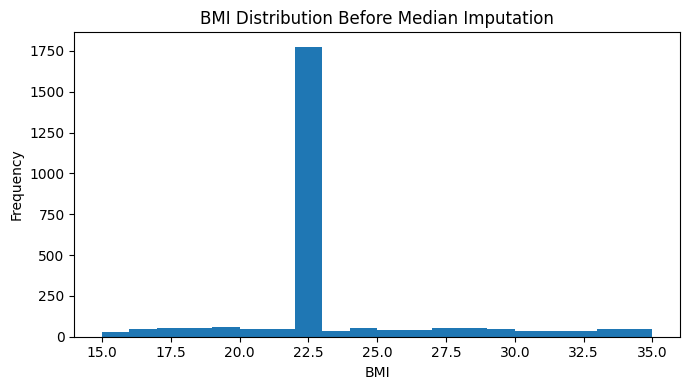

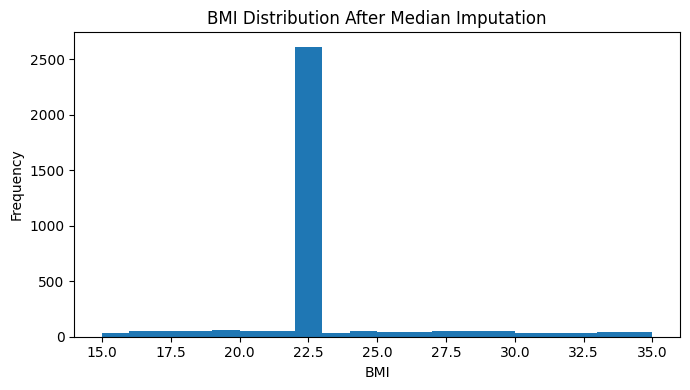

In [55]:
from sklearn.impute import SimpleImputer

# Identify the numerical training features.
numeric_columns = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

print("Numerical columns:")
print(numeric_columns)

# Save values before imputation for comparison.
X_train_before_imputation = X_train.copy()

# Print missing numerical values before imputation.
print("\nMissing numerical values BEFORE imputation:")
print(
    X_train_before_imputation[numeric_columns]
    .isnull()
    .sum()
)

# Create a median imputer.
numeric_imputer = SimpleImputer(
    strategy="median"
)

# Fit and transform TRAINING numerical data only.
X_train[numeric_columns] = numeric_imputer.fit_transform(
    X_train[numeric_columns]
)

print("\nMissing numerical values AFTER imputation:")
print(
    X_train[numeric_columns]
    .isnull()
    .sum()
)

print("\nSample after numerical imputation:")
display(X_train.head())

# Visualize BMI before imputation.
plt.figure(figsize=(7, 4))

plt.hist(
    X_train_before_imputation["BMI"].dropna(),
    bins=20
)

plt.title("BMI Distribution Before Median Imputation")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Visualize BMI after imputation.
plt.figure(figsize=(7, 4))

plt.hist(
    X_train["BMI"],
    bins=20
)

plt.title("BMI Distribution After Median Imputation")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 27. Inspect Categorical and Text Variables Before Cleaning

The remaining categorical/text variables are inspected before standardization:

- `Gender`
- `City`
- `Diabetic`
- `Smoker`
- `Medications`
- `Notes`

The professor specifically instructed us to place `0` for no medication and remove blank medication/note cells.

Deleting entire rows because one of those two fields is blank would remove too much useful data. We therefore calculate how many training rows would remain if those records were deleted, then handle the blank cells without deleting the patient records.

Only training data is inspected.

In [56]:
categorical_columns = [
    "Gender",
    "City",
    "Diabetic",
    "Smoker",
    "Medications",
    "Notes"
]

# Save the original categorical values for before/after comparisons.
X_train_categories_before = (
    X_train[categorical_columns]
    .copy()
)

print("===== MISSING VALUES BEFORE CATEGORICAL PREPROCESSING =====")
print(
    X_train[categorical_columns]
    .isnull()
    .sum()
)

# Print the categories before cleaning.
for column in categorical_columns:
    print(f"\n--- {column} BEFORE CLEANING ---")
    print(
        X_train[column]
        .value_counts(dropna=False)
    )

# Show how much data would be lost by deleting rows
# with blank Medications OR Notes.
blank_medications_or_notes = (
    X_train["Medications"].isnull()
    |
    X_train["Notes"].isnull()
)

rows_remaining_if_deleted = (
    ~blank_medications_or_notes
).sum()

print("\nTraining rows before deleting blanks:")
print(len(X_train))

print(
    "\nRows that would remain if records with blank "
    "Medications OR Notes were deleted:"
)
print(rows_remaining_if_deleted)

print("\nSample before categorical/text preprocessing:")
display(
    X_train[categorical_columns]
    .head(10)
)

===== MISSING VALUES BEFORE CATEGORICAL PREPROCESSING =====
Gender          594
City            374
Diabetic        591
Smoker         1123
Medications    1381
Notes          1401
dtype: int64

--- Gender BEFORE CLEANING ---
Gender
Unknown    608
NaN        594
FEMALE     583
male       576
F          574
M          546
Name: count, dtype: int64

--- City BEFORE CLEANING ---
City
Chicago        377
NaN            374
NY             364
Boston         355
la             353
New York       352
Nwe Yrok       344
chicago        339
newyork        332
Los Angeles    291
Name: count, dtype: int64

--- Diabetic BEFORE CLEANING ---
Diabetic
no         621
NaN        591
N          586
Unknown    568
Yes        567
y          548
Name: count, dtype: int64

--- Smoker BEFORE CLEANING ---
Smoker
NaN          1123
No            597
Former        596
EX-smoker     596
yes           569
Name: count, dtype: int64

--- Medications BEFORE CLEANING ---
Medications
NaN                       1381
Lisinop

,Gender,City,Diabetic,Smoker,Medications,Notes
5018,NaN,Chicago,N,No,"aspirin,metformin",Patient feeling fine 🙂
9262,M,NY,Yes,Former,Lisinopril / Metformin,NaN
3631,NaN,Boston,no,No,NaN,Follow up soon
365,NaN,New York,N,NaN,NaN,NaN
8983,F,Boston,no,NaN,NaN,"BP high, needs recheck"
7420,F,newyork,N,NaN,Aspirin; Metformin,NaN
900,M,New York,N,Former,Lisinopril / Metformin,Follow up soon
1293,male,Boston,y,NaN,NaN,NaN
5817,male,newyork,Unknown,Former,Aspirin; Metformin,Follow up soon
7416,M,Boston,Unknown,NaN,NaN,NaN


## 28. Standardize Categorical Variables and Handle Medications/Notes

The categorical variables contain inconsistent labels that represent the same category.

The following cleaning rules are applied with Python:

- `Gender`: standardize values such as `M`, `male`, `F`, and `FEMALE`.
- `City`: combine alternate spellings such as `NY`, `newyork`, and `Nwe Yrok`.
- `Diabetic`: standardize `Yes`/`No` values.
- `Smoker`: combine `Former` and `EX-smoker`.
- `Medications`: standardize medication combinations and represent no/blank medication as `0`.
- `Notes`: remove extra whitespace and represent blank/missing notes as `No_Notes`.

Missing categorical values are represented as `Unknown` when the true category is not known.

No rows are manually edited or deleted.

In [57]:
# =========================================================
# GENDER
# =========================================================

X_train["Gender"] = (
    X_train["Gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

gender_map = {
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female",
    "unknown": "Unknown"
}

X_train["Gender"] = (
    X_train["Gender"]
    .map(gender_map)
    .fillna("Unknown")
)


# =========================================================
# CITY
# =========================================================

X_train["City"] = (
    X_train["City"]
    .astype("string")
    .str.strip()
    .str.lower()
)

city_map = {
    "boston": "Boston",
    "chicago": "Chicago",
    "ny": "New York",
    "new york": "New York",
    "newyork": "New York",
    "nwe yrok": "New York",
    "la": "Los Angeles",
    "los angeles": "Los Angeles"
}

X_train["City"] = (
    X_train["City"]
    .map(city_map)
    .fillna("Unknown")
)


# =========================================================
# DIABETIC
# =========================================================

X_train["Diabetic"] = (
    X_train["Diabetic"]
    .astype("string")
    .str.strip()
    .str.lower()
)

diabetic_map = {
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No",
    "unknown": "Unknown"
}

X_train["Diabetic"] = (
    X_train["Diabetic"]
    .map(diabetic_map)
    .fillna("Unknown")
)


# =========================================================
# SMOKER
# =========================================================

X_train["Smoker"] = (
    X_train["Smoker"]
    .astype("string")
    .str.strip()
    .str.lower()
)

smoker_map = {
    "yes": "Yes",
    "no": "No",
    "former": "Former",
    "ex-smoker": "Former",
    "unknown": "Unknown"
}

X_train["Smoker"] = (
    X_train["Smoker"]
    .map(smoker_map)
    .fillna("Unknown")
)


# =========================================================
# MEDICATIONS
# =========================================================

# Standardize capitalization and whitespace first.
X_train["Medications"] = (
    X_train["Medications"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "", regex=True)
)

medication_map = {
    "aspirin,metformin": "Aspirin_Metformin",
    "aspirin;metformin": "Aspirin_Metformin",
    "lisinopril/metformin": "Lisinopril_Metformin",
    "none": "0",
    "0": "0"
}

# Fill blank/no-medication entries with 0.
X_train["Medications"] = (
    X_train["Medications"]
    .replace(medication_map)
    .fillna("0")
)


# =========================================================
# NOTES
# =========================================================

# Remove extra whitespace.
X_train["Notes"] = (
    X_train["Notes"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Treat completely empty strings as missing.
X_train["Notes"] = (
    X_train["Notes"]
    .replace("", pd.NA)
)

# Replace blank/missing notes without deleting patient rows.
X_train["Notes"] = (
    X_train["Notes"]
    .fillna("No_Notes")
)

# Standardize the known note categories.
notes_map = {
    "Follow up soon": "Follow_Up_Soon",
    "BP high, needs recheck": "BP_High_Recheck",
    "Patient feeling fine 🙂": "Feeling_Fine"
}

X_train["Notes"] = (
    X_train["Notes"]
    .replace(notes_map)
)


# =========================================================
# VERIFY
# =========================================================

print("Categorical/text cleaning completed successfully.")

for column in categorical_columns:
    print(f"\n--- {column} AFTER CLEANING ---")
    print(
        X_train[column]
        .value_counts(dropna=False)
    )

print("\nRemaining missing values in categorical/text columns:")
print(
    X_train[categorical_columns]
    .isnull()
    .sum()
)

print("\nSample after categorical/text cleaning:")
display(
    X_train[categorical_columns]
    .head(10)
)


Categorical/text cleaning completed successfully.

--- Gender AFTER CLEANING ---
Gender
Unknown    1202
Female     1157
Male       1122
Name: count, dtype: int64

--- City AFTER CLEANING ---
City
New York       1392
Chicago         716
Los Angeles     644
Unknown         374
Boston          355
Name: count, dtype: int64

--- Diabetic AFTER CLEANING ---
Diabetic
No         1207
Unknown    1159
Yes        1115
Name: count, dtype: int64

--- Smoker AFTER CLEANING ---
Smoker
Former     1192
Unknown    1123
No          597
Yes         569
Name: count, dtype: int64

--- Medications AFTER CLEANING ---
Medications
0                       1381
Aspirin_Metformin       1369
Lisinopril_Metformin     731
Name: count, dtype: Int64

--- Notes AFTER CLEANING ---
Notes
No_Notes           1401
BP_High_Recheck     742
Follow_Up_Soon      679
Feeling_Fine        659
Name: count, dtype: Int64

Remaining missing values in categorical/text columns:
Gender         0
City           0
Diabetic       0
Smoker   

,Gender,City,Diabetic,Smoker,Medications,Notes
5018,Unknown,Chicago,No,No,Aspirin_Metformin,Feeling_Fine
9262,Male,New York,Yes,Former,Lisinopril_Metformin,No_Notes
3631,Unknown,Boston,No,No,0,Follow_Up_Soon
365,Unknown,New York,No,Unknown,0,No_Notes
8983,Female,Boston,No,Unknown,0,BP_High_Recheck
7420,Female,New York,No,Unknown,Aspirin_Metformin,No_Notes
900,Male,New York,No,Former,Lisinopril_Metformin,Follow_Up_Soon
1293,Male,Boston,Yes,Unknown,0,No_Notes
5817,Male,New York,Unknown,Former,Aspirin_Metformin,Follow_Up_Soon
7416,Male,Boston,Unknown,Unknown,0,No_Notes


## 29. Visualize Categorical/Text Preprocessing Before and After

Matplotlib is used to demonstrate the effect of categorical/text preprocessing.

The first pair of plots shows how inconsistent `Gender` labels were standardized.

The next pair shows the number of missing `Medications` and `Notes` values before and after preprocessing.

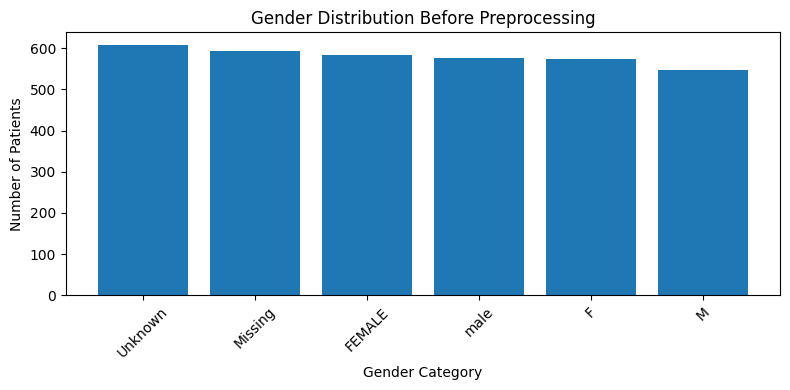

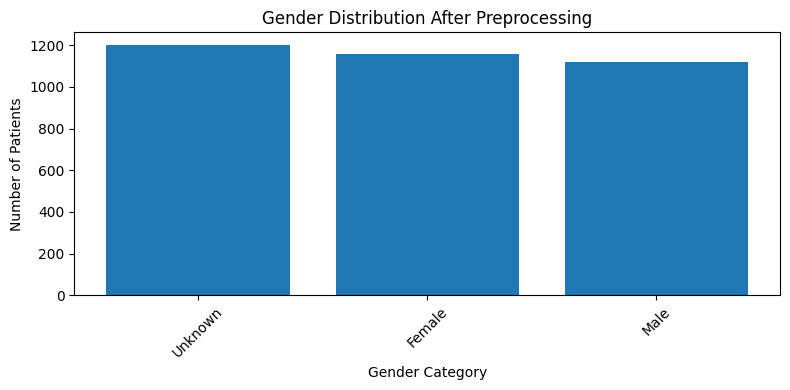

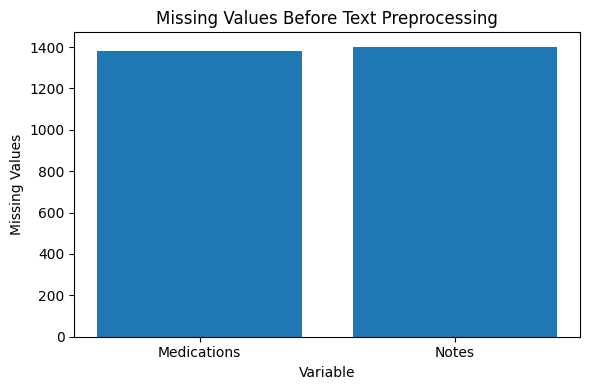

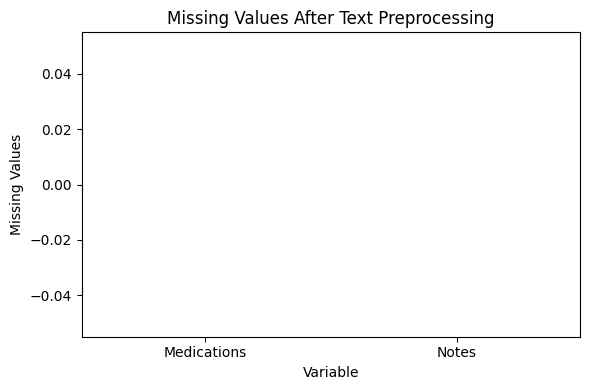

Missing values BEFORE:
Medications    1381
Notes          1401
dtype: int64

Missing values AFTER:
Medications    0
Notes          0
dtype: int64


In [58]:
# =========================================================
# GENDER BEFORE CLEANING
# =========================================================

gender_before = (
    X_train_categories_before["Gender"]
    .astype("string")
    .fillna("Missing")
    .value_counts()
)

plt.figure(figsize=(8, 4))

plt.bar(
    gender_before.index.astype(str),
    gender_before.values
)

plt.title("Gender Distribution Before Preprocessing")
plt.xlabel("Gender Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# GENDER AFTER CLEANING
# =========================================================

gender_after = (
    X_train["Gender"]
    .value_counts()
)

plt.figure(figsize=(8, 4))

plt.bar(
    gender_after.index.astype(str),
    gender_after.values
)

plt.title("Gender Distribution After Preprocessing")
plt.xlabel("Gender Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# MISSING MEDICATIONS / NOTES BEFORE AND AFTER
# =========================================================

missing_text_before = pd.Series({
    "Medications":
        X_train_categories_before["Medications"]
        .isnull()
        .sum(),
    "Notes":
        X_train_categories_before["Notes"]
        .isnull()
        .sum()
})

missing_text_after = pd.Series({
    "Medications":
        X_train["Medications"]
        .isnull()
        .sum(),
    "Notes":
        X_train["Notes"]
        .isnull()
        .sum()
})

plt.figure(figsize=(6, 4))

plt.bar(
    missing_text_before.index,
    missing_text_before.values
)

plt.title("Missing Values Before Text Preprocessing")
plt.xlabel("Variable")
plt.ylabel("Missing Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))

plt.bar(
    missing_text_after.index,
    missing_text_after.values
)

plt.title("Missing Values After Text Preprocessing")
plt.xlabel("Variable")
plt.ylabel("Missing Values")
plt.tight_layout()
plt.show()

print("Missing values BEFORE:")
print(missing_text_before)

print("\nMissing values AFTER:")
print(missing_text_after)


## 30. Encode Categorical Variables Using One-Hot Encoding

Machine-learning models require numerical input, so the cleaned categorical variables must be converted into numerical features.

The variables `Gender`, `Diabetic`, `Smoker`, `Medications`, and `Notes` are converted with One-Hot Encoding. `City` is handled with frequency encoding instead of separate One-Hot columns, following the instructor's feedback. This represents each city by its frequency in the training data without creating many city-specific dummy columns.

This step performs the required categorical encoding and One-Hot Encoding. The encoder is fitted using the training data only. The testing dataset remains separate and untouched during preprocessing development.

In [59]:
from sklearn.preprocessing import OneHotEncoder

# =========================================================
# CITY FREQUENCY ENCODING
# =========================================================

city_frequency = (
    X_train["City"]
    .value_counts(normalize=True)
    .round(4)
)

X_train["City_Frequency"] = (
    X_train["City"]
    .map(city_frequency)
    .round(4)
)

print("City frequency encoding completed.")

print("\nCity frequency:")
print(city_frequency)

print("\nSample of City Frequency Encoding:")
display(
    X_train[["City", "City_Frequency"]].head(10)
)


# =========================================================
# SELECT CATEGORICAL COLUMNS FOR ONE-HOT ENCODING
# =========================================================

# City is intentionally excluded because it uses frequency encoding.
columns_to_encode = [
    "Gender",
    "Diabetic",
    "Smoker",
    "Medications",
    "Notes"
]


# =========================================================
# CREATE THE ONE-HOT ENCODER
# =========================================================

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=int
)


# =========================================================
# FIT AND TRANSFORM TRAINING DATA
# =========================================================

train_encoded_array = encoder.fit_transform(
    X_train[columns_to_encode]
)

encoded_column_names = encoder.get_feature_names_out(
    columns_to_encode
)


# =========================================================
# CREATE DATAFRAME WITH ENCODED VALUES
# =========================================================

train_encoded_df = pd.DataFrame(
    train_encoded_array,
    columns=encoded_column_names,
    index=X_train.index
)


# =========================================================
# REMOVE ORIGINAL CATEGORICAL COLUMNS
# =========================================================

# Remove the One-Hot categorical columns AND original City.
X_train_encoded = X_train.drop(
    columns=columns_to_encode + ["City"]
).copy()


# =========================================================
# ADD ENCODED FEATURES
# =========================================================

X_train_encoded = pd.concat(
    [
        X_train_encoded,
        train_encoded_df
    ],
    axis=1
)


# =========================================================
# VERIFY ENCODING
# =========================================================

print("\nOne-Hot Encoding completed successfully.")

print("\nNew One-Hot Encoded columns:")
print(encoded_column_names)

print("\nTraining shape before encoding:")
print(X_train.shape)

print("\nTraining shape after encoding:")
print(X_train_encoded.shape)

print("\nSample of encoded categorical data:")
display(
    X_train_encoded[
        encoded_column_names
    ].head(10)
)


# Check whether any text columns remain
remaining_non_numeric = (
    X_train_encoded
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("\nRemaining non-numerical columns:")
print(remaining_non_numeric)

print("\nCity_Frequency included:")
print("City_Frequency" in X_train_encoded.columns)

City frequency encoding completed.

City frequency:
City
New York       0.3999
Chicago        0.2057
Los Angeles    0.1850
Unknown        0.1074
Boston         0.1020
Name: proportion, dtype: float64

Sample of City Frequency Encoding:


,City,City_Frequency
5018,Chicago,0.2057
9262,New York,0.3999
3631,Boston,0.1020
365,New York,0.3999
8983,Boston,0.1020
7420,New York,0.3999
900,New York,0.3999
1293,Boston,0.1020
5817,New York,0.3999
7416,Boston,0.1020



One-Hot Encoding completed successfully.

New One-Hot Encoded columns:
['Gender_Female' 'Gender_Male' 'Gender_Unknown' 'Diabetic_No'
 'Diabetic_Unknown' 'Diabetic_Yes' 'Smoker_Former' 'Smoker_No'
 'Smoker_Unknown' 'Smoker_Yes' 'Medications_0'
 'Medications_Aspirin_Metformin' 'Medications_Lisinopril_Metformin'
 'Notes_BP_High_Recheck' 'Notes_Feeling_Fine' 'Notes_Follow_Up_Soon'
 'Notes_No_Notes']

Training shape before encoding:
(3481, 16)

Training shape after encoding:
(3481, 27)

Sample of encoded categorical data:


,Gender_Female,Gender_Male,Gender_Unknown,Diabetic_No,Diabetic_Unknown,Diabetic_Yes,Smoker_Former,Smoker_No,Smoker_Unknown,Smoker_Yes,Medications_0,Medications_Aspirin_Metformin,Medications_Lisinopril_Metformin,Notes_BP_High_Recheck,Notes_Feeling_Fine,Notes_Follow_Up_Soon,Notes_No_Notes
5018,0,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,0
9262,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1
3631,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,0
365,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,1
8983,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0
7420,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1
900,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0
1293,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1
5817,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0
7416,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1



Remaining non-numerical columns:
[]

City_Frequency included:
True


## 31. Balance the Training Dataset

The target variable `Has_Disease` contains two classes. The training classes are already close in size, but a small difference remains.

To demonstrate the required class-balancing technique, random oversampling is used to increase the minority class until it contains the same number of observations as the majority class.

Only the training dataset is balanced. The testing dataset is not used or modified.

Matplotlib is used to compare the class distribution before and after balancing.

Class distribution BEFORE balancing:
Has_Disease
0    1759
1    1722
Name: count, dtype: int64


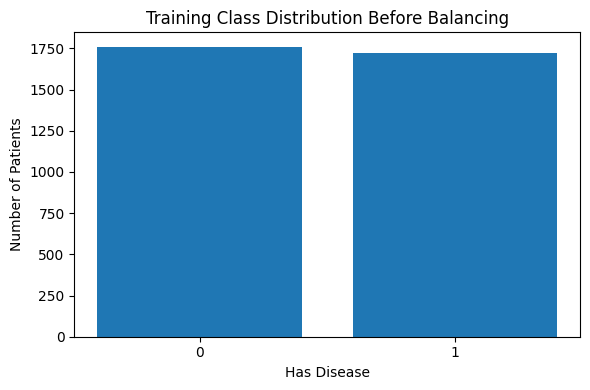


Majority class: 0
Minority class: 1

Class distribution AFTER balancing:
Has_Disease
0    1759
1    1759
Name: count, dtype: int64


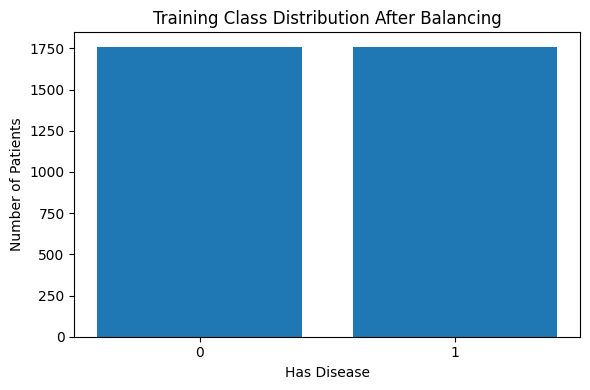


Training rows before balancing:
3481

Training rows after balancing:
3518


In [60]:
# =========================================================
# CLASS DISTRIBUTION BEFORE BALANCING
# =========================================================

class_counts_before = (
    y_train
    .value_counts()
    .sort_index()
)

print("Class distribution BEFORE balancing:")
print(class_counts_before)


# Plot class distribution before balancing.
plt.figure(figsize=(6, 4))

plt.bar(
    class_counts_before.index.astype(str),
    class_counts_before.values
)

plt.title("Training Class Distribution Before Balancing")
plt.xlabel("Has Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.show()


# =========================================================
# COMBINE FEATURES AND TARGET TEMPORARILY
# =========================================================

# Combine the encoded training features with the target so
# each patient's features stay connected to the correct label.
training_data = X_train_encoded.copy()

training_data["Has_Disease"] = y_train


# Count each class.
class_counts = (
    training_data["Has_Disease"]
    .value_counts()
)

# Identify the majority and minority classes.
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

print("\nMajority class:", majority_class)
print("Minority class:", minority_class)


# Separate majority-class observations.
majority_data = training_data[
    training_data["Has_Disease"] == majority_class
]

# Separate minority-class observations.
minority_data = training_data[
    training_data["Has_Disease"] == minority_class
]


# =========================================================
# RANDOM OVERSAMPLING
# =========================================================

# Randomly select minority-class records with replacement
# until both classes contain the same number of observations.
minority_oversampled = minority_data.sample(
    n=len(majority_data),
    replace=True,
    random_state=42
)

# Combine the majority and oversampled minority classes.
training_balanced = pd.concat(
    [
        majority_data,
        minority_oversampled
    ]
)

# Shuffle the balanced training dataset.
training_balanced = (
    training_balanced
    .sample(
        frac=1,
        random_state=42
    )
    .reset_index(drop=True)
)


# =========================================================
# SEPARATE FEATURES AND TARGET AGAIN
# =========================================================

X_train_balanced = training_balanced.drop(
    columns=["Has_Disease"]
)

y_train_balanced = (
    training_balanced["Has_Disease"]
    .astype(int)
)


# =========================================================
# CLASS DISTRIBUTION AFTER BALANCING
# =========================================================

class_counts_after = (
    y_train_balanced
    .value_counts()
    .sort_index()
)

print("\nClass distribution AFTER balancing:")
print(class_counts_after)


# Plot the balanced target distribution.
plt.figure(figsize=(6, 4))

plt.bar(
    class_counts_after.index.astype(str),
    class_counts_after.values
)

plt.title("Training Class Distribution After Balancing")
plt.xlabel("Has Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.show()


# Show how the training size changed.
print("\nTraining rows before balancing:")
print(len(X_train_encoded))

print("\nTraining rows after balancing:")
print(len(X_train_balanced))

## 32. Verify Categorical Preprocessing and Class Balancing

The categorical preprocessing stage is verified before the training data continues to feature scaling and normalization.

This check confirms that:

- categorical values were standardized;
- blank medication values were represented as `0`;
- blank note values were represented as `No_Notes`;
- categorical missing values were removed;
- categorical variables were converted into numerical features using One-Hot Encoding;
- no text columns remain;
- class balancing was performed only on the training data;
- sample processed records can be inspected before continuing.

The testing dataset remains separate and untouched.

In [61]:
print("===== CATEGORICAL PREPROCESSING VERIFICATION =====")


# =========================================================
# CHECK MISSING VALUES
# =========================================================

print("\nRemaining missing values:")
print(
    X_train_balanced
    .isnull()
    .sum()
    .sum()
)


# =========================================================
# CHECK DATA TYPES
# =========================================================

remaining_non_numeric = (
    X_train_balanced
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("\nRemaining non-numerical columns:")
print(remaining_non_numeric)


# =========================================================
# CHECK FINAL TRAINING SIZE
# =========================================================

print("\nBalanced training feature shape:")
print(X_train_balanced.shape)

print("\nBalanced training target shape:")
print(y_train_balanced.shape)


# =========================================================
# CHECK FINAL CLASS DISTRIBUTION
# =========================================================

print("\nFinal training target distribution:")
print(
    y_train_balanced
    .value_counts()
    .sort_index()
)


# =========================================================
# PRINT SAMPLE DATA
# =========================================================

print("\nSample of processed training data:")
display(
    X_train_balanced.head(10)
)


print(
    "\nCategorical preprocessing and class balancing "
    "are complete."
)

print(
    "The testing dataset has remained separate "
    "and untouched."
)

===== CATEGORICAL PREPROCESSING VERIFICATION =====

Remaining missing values:
0

Remaining non-numerical columns:
[]

Balanced training feature shape:
(3518, 27)

Balanced training target shape:
(3518,)

Final training target distribution:
Has_Disease
0    1759
1    1759
Name: count, dtype: int64

Sample of processed training data:


,Age,BMI,Heart_Rate,Cholesterol_Level,Follow_Up,Systolic_BP,Diastolic_BP,Visit_Year,Visit_Month,City_Frequency,...,Smoker_No,Smoker_Unknown,Smoker_Yes,Medications_0,Medications_Aspirin_Metformin,Medications_Lisinopril_Metformin,Notes_BP_High_Recheck,Notes_Feeling_Fine,Notes_Follow_Up_Soon,Notes_No_Notes
0,20.0,22.0,80.0,190.0,14.0,120.0,80.0,2024.0,5.0,0.1020,...,0,0,1,0,1,0,0,1,0,0
1,25.0,24.1,80.0,190.0,14.0,120.0,80.0,2023.0,2.0,0.2057,...,0,1,0,0,1,0,0,0,1,0
2,20.0,22.5,107.0,190.0,14.0,120.0,80.0,2021.0,8.0,0.2057,...,0,0,0,0,1,0,0,0,1,0
3,5.0,22.0,101.0,190.0,14.0,120.0,80.0,2020.0,8.0,0.3999,...,0,0,1,1,0,0,0,0,1,0
4,25.0,22.5,80.0,190.0,14.0,120.0,80.0,2020.0,6.0,0.3999,...,0,0,0,0,1,0,0,0,0,1
5,25.0,22.5,80.0,190.0,14.0,120.0,80.0,2020.0,9.0,0.1850,...,0,0,0,1,0,0,0,0,0,1
6,5.0,22.5,80.0,190.0,14.0,120.0,80.0,2023.0,4.0,0.3999,...,0,0,1,0,1,0,1,0,0,0
7,98.0,22.5,97.0,190.0,14.0,120.0,80.0,2025.0,2.0,0.2057,...,0,1,0,0,1,0,1,0,0,0
8,25.0,22.5,90.0,190.0,14.0,120.0,80.0,2022.0,12.0,0.2057,...,0,1,0,0,1,0,1,0,0,0
9,5.0,22.0,80.0,190.0,14.0,120.0,80.0,2023.0,7.0,0.3999,...,0,0,0,0,0,1,0,0,0,1



Categorical preprocessing and class balancing are complete.
The testing dataset has remained separate and untouched.


## 33. Feature Engineering

Feature engineering is performed on the processed training dataset to create additional meaningful numerical features that may help machine-learning models identify patterns related to disease.

The following features are created:

- **Pulse_Pressure:** Difference between systolic and diastolic blood pressure.
- **Mean_Arterial_Pressure:** An estimate of average arterial blood pressure.
- **Cholesterol_Age_Ratio:** Cholesterol level relative to patient age.

These features are created using the training data. The testing dataset remains separate and is not used during feature engineering development.


In [62]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Create a copy of the balanced training data
X_train_featured = X_train_balanced.copy()

# 1. Pulse Pressure
X_train_featured["Pulse_Pressure"] = (
    X_train_featured["Systolic_BP"] -
    X_train_featured["Diastolic_BP"]
)

# 2. Mean Arterial Pressure
X_train_featured["Mean_Arterial_Pressure"] = (
    X_train_featured["Diastolic_BP"] +
    (X_train_featured["Pulse_Pressure"] / 3)
)

# 3. Cholesterol-to-Age Ratio
X_train_featured["Cholesterol_Age_Ratio"] = (
    X_train_featured["Cholesterol_Level"] /
    X_train_featured["Age"].replace(0, 1)
)

print("Feature engineering completed successfully.")

print("\nTraining shape before feature engineering:")
print(X_train_balanced.shape)

print("\nTraining shape after feature engineering:")
print(X_train_featured.shape)

print("\nNew engineered features:")
display(
    X_train_featured[
        [
            "Pulse_Pressure",
            "Mean_Arterial_Pressure",
            "Cholesterol_Age_Ratio"
        ]
    ].head(10)
)

Feature engineering completed successfully.

Training shape before feature engineering:
(3518, 27)

Training shape after feature engineering:
(3518, 30)

New engineered features:


,Pulse_Pressure,Mean_Arterial_Pressure,Cholesterol_Age_Ratio
0,40.0,93.333333,9.500000
1,40.0,93.333333,7.600000
2,40.0,93.333333,9.500000
3,40.0,93.333333,38.000000
4,40.0,93.333333,7.600000
5,40.0,93.333333,7.600000
6,40.0,93.333333,38.000000
7,40.0,93.333333,1.938776
8,40.0,93.333333,7.600000
9,40.0,93.333333,38.000000


In [63]:
# ============================================================
# DISPLAY CLEANED NUMERICAL VALUES BEFORE NORMALIZATION
# AND SCALING
# ============================================================

print(
    "Cleaned numerical values BEFORE normalization and scaling:"
)

display(
    X_train_featured[
        [
            "Age",
            "BMI",
            "Heart_Rate",
            "Cholesterol_Level",
            "Follow_Up",
            "Systolic_BP",
            "Diastolic_BP",
            "Pulse_Pressure",
            "Mean_Arterial_Pressure",
            "Cholesterol_Age_Ratio"
        ]
    ].head(15)
)

Cleaned numerical values BEFORE normalization and scaling:


,Age,BMI,Heart_Rate,Cholesterol_Level,Follow_Up,Systolic_BP,Diastolic_BP,Pulse_Pressure,Mean_Arterial_Pressure,Cholesterol_Age_Ratio
0,20.0,22.0,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,9.500000
1,25.0,24.1,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,7.600000
2,20.0,22.5,107.0,190.0,14.0,120.0,80.0,40.0,93.333333,9.500000
3,5.0,22.0,101.0,190.0,14.0,120.0,80.0,40.0,93.333333,38.000000
4,25.0,22.5,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,7.600000
5,25.0,22.5,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,7.600000
6,5.0,22.5,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,38.000000
7,98.0,22.5,97.0,190.0,14.0,120.0,80.0,40.0,93.333333,1.938776
8,25.0,22.5,90.0,190.0,14.0,120.0,80.0,40.0,93.333333,7.600000
9,5.0,22.0,80.0,190.0,14.0,120.0,80.0,40.0,93.333333,38.000000


## 34. Normalize Skewed Numerical Features

Normalization is applied to selected continuous numerical features in the **balanced training dataset**.

The skewness of candidate features is checked first. Features with noticeable positive skewness (`> 0.5`) and non-negative values are transformed with `np.log1p()`.

Blood-pressure features are intentionally excluded from the log transformation because their clinical meaning is easier to interpret before the later Min-Max scaling step.

Matplotlib is used to show a before/after distribution comparison.

Skewness BEFORE normalization:


,0
Cholesterol_Age_Ratio,3.911160
Age,1.780785
BMI,1.691774
Heart_Rate,0.884123



Features selected for normalization:
['Age', 'BMI', 'Heart_Rate', 'Cholesterol_Age_Ratio']

Skewness AFTER normalization:


,0
BMI,0.977090
Cholesterol_Age_Ratio,0.370105
Heart_Rate,-0.265773
Age,-0.134872


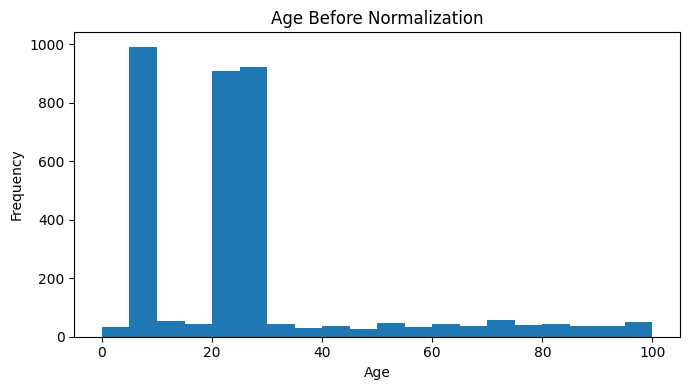

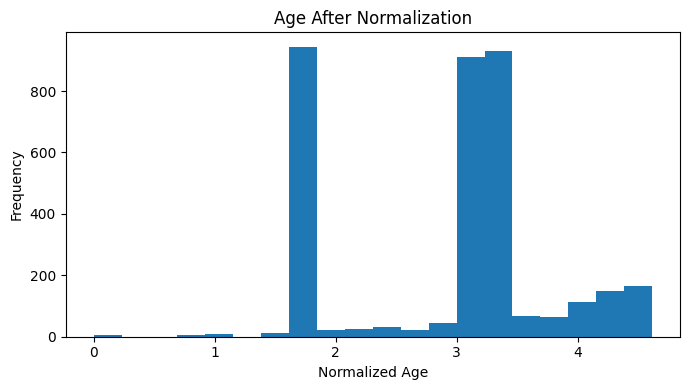


Sample after normalization:


,Age,BMI,Heart_Rate,Cholesterol_Age_Ratio
0,3.044522,3.135494,4.394449,2.351375
1,3.258097,3.222868,4.394449,2.151762
2,3.044522,3.157000,4.682131,2.351375
3,1.791759,3.135494,4.624973,3.663562
4,3.258097,3.157000,4.394449,2.151762
5,3.258097,3.157000,4.394449,2.151762
6,1.791759,3.157000,4.394449,3.663562
7,4.595120,3.157000,4.584967,1.077993
8,3.258097,3.157000,4.510860,2.151762
9,1.791759,3.135494,4.394449,3.663562


In [64]:
# ============================================================
# NORMALIZE SKEWED NUMERICAL FEATURES
# ============================================================

X_train_normalized = X_train_featured.copy()

normalization_candidates = [
    "Age",
    "BMI",
    "Heart_Rate",
    "Cholesterol_Age_Ratio"
]

# Check skewness before normalization.
skewness_before = (
    X_train_normalized[normalization_candidates]
    .skew()
    .sort_values(key=abs, ascending=False)
)

print("Skewness BEFORE normalization:")
display(skewness_before)

# Select positively skewed, non-negative features.
columns_to_normalize = [
    column
    for column in normalization_candidates
    if (
        skewness_before[column] > 0.5
        and X_train_normalized[column].min(skipna=True) >= 0
    )
]

print("\nFeatures selected for normalization:")
print(columns_to_normalize)

# Save one feature for the before/after plot.
if columns_to_normalize:
    feature_to_plot = columns_to_normalize[0]
    feature_before = X_train_normalized[feature_to_plot].copy()

    for column in columns_to_normalize:
        X_train_normalized[column] = np.log1p(
            X_train_normalized[column]
        )

    skewness_after = (
        X_train_normalized[normalization_candidates]
        .skew()
        .sort_values(key=abs, ascending=False)
    )

    print("\nSkewness AFTER normalization:")
    display(skewness_after)

    plt.figure(figsize=(7, 4))
    plt.hist(feature_before.dropna(), bins=20)
    plt.title(f"{feature_to_plot} Before Normalization")
    plt.xlabel(feature_to_plot)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(
        X_train_normalized[feature_to_plot].dropna(),
        bins=20
    )
    plt.title(f"{feature_to_plot} After Normalization")
    plt.xlabel(f"Normalized {feature_to_plot}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

print("\nSample after normalization:")
display(
    X_train_normalized[normalization_candidates].head(10)
)

## 35. Scale Features and Fill Remaining Missing Values

Continuous numerical measurements are transformed with Min-Max Scaling to the `0–1` range.

`Visit_Year` and `Visit_Month` are intentionally **not scaled** so their calendar meaning remains interpretable. The year and month are also explicitly converted to integer values because they are already complete numerical date features.

After scaling, any remaining numerical missing values are filled using the **training-data median**. This completes the required missing-value preprocessing without using the test set.

Matplotlib is used to compare a feature before and after scaling.

Min-Max scaling completed.

Minimum values after scaling:
Age                       0.0
BMI                       0.0
Heart_Rate                0.0
Cholesterol_Level         0.0
Follow_Up                 0.0
Systolic_BP               0.0
Diastolic_BP              0.0
Pulse_Pressure            0.0
Mean_Arterial_Pressure    0.0
Cholesterol_Age_Ratio     0.0
dtype: float64

Maximum values after scaling:
Age                       1.0
BMI                       1.0
Heart_Rate                1.0
Cholesterol_Level         1.0
Follow_Up                 1.0
Systolic_BP               1.0
Diastolic_BP              1.0
Pulse_Pressure            1.0
Mean_Arterial_Pressure    1.0
Cholesterol_Age_Ratio     1.0
dtype: float64

Visit Year values:
Visit_Year
2020    603
2021    574
2022    587
2023    627
2024    645
2025    482
Name: count, dtype: Int64

Visit Month values:
Visit_Month
1     316
2     276
3     343
4     254
5     314
6     343
7     345
8     312
9     268
10    263
11    238
12    246

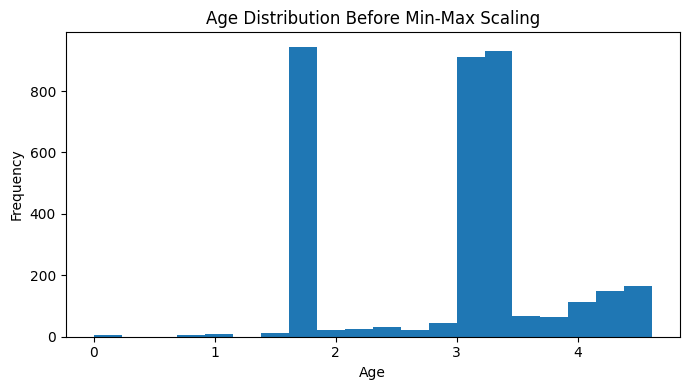

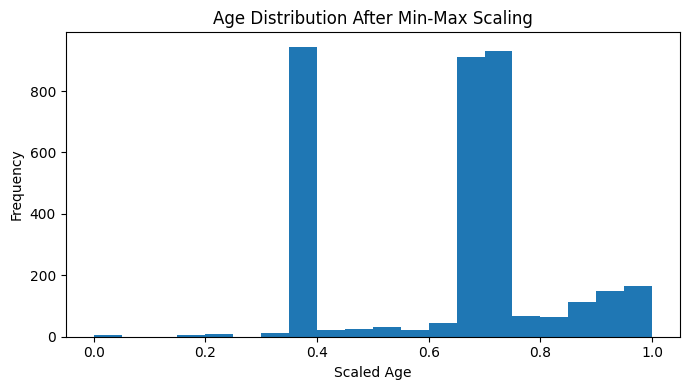


Sample of final scaled numerical features:


,Age,BMI,Heart_Rate,Cholesterol_Level,Follow_Up,Systolic_BP,Diastolic_BP,Pulse_Pressure,Mean_Arterial_Pressure,Cholesterol_Age_Ratio
0,0.659684,0.447518,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.288442
1,0.705961,0.555262,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.243693
2,0.659684,0.474038,0.868445,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.288442
3,0.388237,0.447518,0.802286,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.582605
4,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.243693
5,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.243693
6,0.388237,0.474038,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.582605
7,0.995666,0.474038,0.755982,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.002978
8,0.705961,0.474038,0.670205,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.243693
9,0.388237,0.447518,0.535466,0.0,0.0,0.428571,0.5,0.393939,0.458333,0.582605



Sample of Visit Year and Month:


,Visit_Year,Visit_Month
0,2024,5
1,2023,2
2,2021,8
3,2020,8
4,2020,6
5,2020,9
6,2023,4
7,2025,2
8,2022,12
9,2023,7


In [65]:
# ============================================================
# SCALE CONTINUOUS FEATURES AND IMPUTE REMAINING MISSING VALUES
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

X_train_scaled = X_train_normalized.copy()

# Keep calendar features interpretable.
X_train_scaled["Visit_Year"] = (
    pd.to_numeric(
        X_train_scaled["Visit_Year"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

X_train_scaled["Visit_Month"] = (
    pd.to_numeric(
        X_train_scaled["Visit_Month"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

columns_to_scale = [
    "Age",
    "BMI",
    "Heart_Rate",
    "Cholesterol_Level",
    "Follow_Up",
    "Systolic_BP",
    "Diastolic_BP",
    "Pulse_Pressure",
    "Mean_Arterial_Pressure",
    "Cholesterol_Age_Ratio"
]

age_before_scaling = X_train_scaled["Age"].copy()

scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled[columns_to_scale] = scaler.fit_transform(
    X_train_scaled[columns_to_scale]
)

print("Min-Max scaling completed.")

print("\nMinimum values after scaling:")
print(
    X_train_scaled[columns_to_scale].min()
)

print("\nMaximum values after scaling:")
print(
    X_train_scaled[columns_to_scale].max()
)

print("\nVisit Year values:")
print(
    X_train_scaled["Visit_Year"].value_counts().sort_index()
)

print("\nVisit Month values:")
print(
    X_train_scaled["Visit_Month"].value_counts().sort_index()
)

# ------------------------------------------------------------
# FILL ALL REMAINING NUMERICAL MISSING VALUES
# ------------------------------------------------------------

numeric_columns_final = (
    X_train_scaled
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

final_imputer = SimpleImputer(strategy="median")

X_train_scaled[numeric_columns_final] = (
    final_imputer.fit_transform(
        X_train_scaled[numeric_columns_final]
    )
)

print("\nRemaining missing values after median imputation:")
print(
    X_train_scaled.isna().sum().sum()
)

# Convert calendar features back to regular integers after
# imputation. They should have no missing values.
X_train_scaled["Visit_Year"] = (
    X_train_scaled["Visit_Year"]
    .round()
    .astype(int)
)

X_train_scaled["Visit_Month"] = (
    X_train_scaled["Visit_Month"]
    .round()
    .astype(int)
)

# ------------------------------------------------------------
# BEFORE / AFTER SCALING VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.hist(age_before_scaling.dropna(), bins=20)
plt.title("Age Distribution Before Min-Max Scaling")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(X_train_scaled["Age"], bins=20)
plt.title("Age Distribution After Min-Max Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nSample of final scaled numerical features:")
display(
    X_train_scaled[columns_to_scale].head(10)
)

print("\nSample of Visit Year and Month:")
display(
    X_train_scaled[
        ["Visit_Year", "Visit_Month"]
    ].head(10)
)

## 36. Final Verification and Export of the Clean Training Dataset

The final training dataset is verified before export.

The checks confirm:

- feature and target row counts match;
- no missing values remain;
- all predictor columns are numerical;
- no infinite values are present;
- the balanced target distribution is retained;
- the final processed sample can be inspected;
- the clean training dataset can be exported to CSV.

The testing dataset remains separate and untouched.

In [66]:
# ============================================================
# FINAL VERIFICATION AND EXPORT
# ============================================================

import numpy as np

print("===== FINAL PREPROCESSING VERIFICATION =====")

# ------------------------------------------------------------
# CITY CHECK
# ------------------------------------------------------------

print("\nOriginal City column present:")
print("City" in X_train_scaled.columns)

print("\nCity_Frequency present:")
print("City_Frequency" in X_train_scaled.columns)

# The original City text column should already have been
# removed during frequency encoding.
if "City" in X_train_scaled.columns:
    X_train_scaled = X_train_scaled.drop(columns=["City"])

# ------------------------------------------------------------
# FEATURE / TARGET SHAPES
# ------------------------------------------------------------

print("\nFinal feature shape:")
print(X_train_scaled.shape)

print("\nFinal target shape:")
print(y_train_balanced.shape)

rows_match = len(X_train_scaled) == len(y_train_balanced)

print("\nFeature and target row counts match:")
print(rows_match)

# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

remaining_missing = X_train_scaled.isna().sum().sum()

print("\nRemaining missing feature values:")
print(remaining_missing)

# ------------------------------------------------------------
# NON-NUMERICAL FEATURES
# ------------------------------------------------------------

non_numeric_columns = (
    X_train_scaled
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("\nRemaining non-numerical columns:")
print(non_numeric_columns)

# ------------------------------------------------------------
# INFINITE VALUES
# ------------------------------------------------------------

infinite_values = np.isinf(
    X_train_scaled.to_numpy(dtype=float)
).sum()

print("\nInfinite values:")
print(infinite_values)

# ------------------------------------------------------------
# TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\nFinal Has_Disease distribution:")
print(
    y_train_balanced
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# COMBINE FEATURES AND TARGET
# ------------------------------------------------------------

final_clean_training = X_train_scaled.copy()

final_clean_training["Has_Disease"] = (
    y_train_balanced.to_numpy()
)

print("\nFinal clean training dataset shape:")
print(final_clean_training.shape)

print("\nSample of final clean training data:")
display(
    final_clean_training.head(10)
)

# ------------------------------------------------------------
# FINAL CHECKS
# ------------------------------------------------------------

final_missing = (
    final_clean_training.isna().sum().sum()
)

final_non_numeric = (
    final_clean_training
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("\nTotal missing values in final dataset:")
print(final_missing)

print("\nFinal non-numerical columns:")
print(final_non_numeric)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

output_file = (
    "Patient_Health_Records_Clean_Training.csv"
)

final_clean_training.to_csv(
    output_file,
    index=False
)

print(
    "\nFinal clean training dataset successfully saved as:"
)

print(output_file)

print(
    "\nThe testing dataset remains separate and untouched."
)

===== FINAL PREPROCESSING VERIFICATION =====

Original City column present:
False

City_Frequency present:
True

Final feature shape:
(3518, 30)

Final target shape:
(3518,)

Feature and target row counts match:
True

Remaining missing feature values:
0

Remaining non-numerical columns:
[]

Infinite values:
0

Final Has_Disease distribution:
Has_Disease
0    1759
1    1759
Name: count, dtype: int64

Final clean training dataset shape:
(3518, 31)

Sample of final clean training data:


,Age,BMI,Heart_Rate,Cholesterol_Level,Follow_Up,Systolic_BP,Diastolic_BP,Visit_Year,Visit_Month,City_Frequency,...,Medications_Aspirin_Metformin,Medications_Lisinopril_Metformin,Notes_BP_High_Recheck,Notes_Feeling_Fine,Notes_Follow_Up_Soon,Notes_No_Notes,Pulse_Pressure,Mean_Arterial_Pressure,Cholesterol_Age_Ratio,Has_Disease
0,0.659684,0.447518,0.535466,0.0,0.0,0.428571,0.5,2024,5,0.1020,...,1.0,0.0,0.0,1.0,0.0,0.0,0.393939,0.458333,0.288442,1
1,0.705961,0.555262,0.535466,0.0,0.0,0.428571,0.5,2023,2,0.2057,...,1.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.243693,0
2,0.659684,0.474038,0.868445,0.0,0.0,0.428571,0.5,2021,8,0.2057,...,1.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.288442,0
3,0.388237,0.447518,0.802286,0.0,0.0,0.428571,0.5,2020,8,0.3999,...,0.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.582605,0
4,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,2020,6,0.3999,...,1.0,0.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.243693,1
5,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,2020,9,0.1850,...,0.0,0.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.243693,0
6,0.388237,0.474038,0.535466,0.0,0.0,0.428571,0.5,2023,4,0.3999,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.582605,0
7,0.995666,0.474038,0.755982,0.0,0.0,0.428571,0.5,2025,2,0.2057,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.002978,0
8,0.705961,0.474038,0.670205,0.0,0.0,0.428571,0.5,2022,12,0.2057,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.243693,0
9,0.388237,0.447518,0.535466,0.0,0.0,0.428571,0.5,2023,7,0.3999,...,0.0,1.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.582605,1



Total missing values in final dataset:
0

Final non-numerical columns:
[]

Final clean training dataset successfully saved as:
Patient_Health_Records_Clean_Training.csv

The testing dataset remains separate and untouched.


## Conclusion

This project transformed the raw Patient Health Records dataset into a clean numerical dataset that can be used for future machine learning work. We completed the required 70/30 train-test split before EDA and developed the preprocessing workflow using only the training data, while the testing data remained separate. The preprocessing process included cleaning invalid and inconsistent values, handling missing data, removing unnecessary identifiers, correcting Age and Blood Pressure values, using frequency encoding for City, applying One-Hot Encoding to the remaining categorical variables, balancing the target classes, creating new features, normalizing selected distributions, and scaling continuous numerical features. Matplotlib visualizations and printed samples helped us compare the data before and after important preprocessing steps and verify that the transformations worked as expected.

After preprocessing and class balancing, the final training dataset contains 3,518 records and 31 columns, including the `Has_Disease` target. Both target classes contain 1,759 records, and the final dataset contains no missing values, non-numerical columns, or infinite values. All changes were completed through Python instead of manually editing the original dataset, which makes the workflow easier to reproduce and review. The final clean training dataset is now ready for the next stage of the project, where it can be used to train and evaluate a binary classification model for predicting `Has_Disease`.